<a href="https://colab.research.google.com/github/chaymaebouabdellah24-tech/SunPath-Predictor/blob/main/SunPath_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Installer XGBoost
!pip install xgboost

In [2]:
#Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [3]:
#Charger les datasets
generation = pd.read_csv('Plant_1_Generation_Data.csv')
weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

In [ ]:
#Explorer les données
generation.head()
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [20]:
#Convertir les dates
generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

In [21]:
#faire le megre
data = pd.merge(generation, weather, on='DATE_TIME', how='inner')

print(data.shape)

(68774, 12)


In [22]:
#Vérifier le dataset final
data.head()
data.shape

(68774, 12)

In [23]:
#Convertir la date
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'])

In [24]:
#Créer des variables temporelles
data['hour'] = data['DATE_TIME'].dt.hour
data['day'] = data['DATE_TIME'].dt.day
data['month'] = data['DATE_TIME'].dt.month

In [25]:
#Choisir les variables (features)
X = data[['IRRADIATION',
          'AMBIENT_TEMPERATURE',
          'MODULE_TEMPERATURE',
          'hour']]

In [26]:
#Variable cible
y = data['AC_POWER']

In [27]:
#Séparer Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
#Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [29]:
#Evaluation Linear Regression
print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))

Linear Regression
MAE: 26.2979657748521
R2: 0.9800290556767175


In [30]:
#Random Forest
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [31]:
#Evaluation Random Forest
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))

Random Forest
MAE: 16.373826102417915
R2: 0.9865280532472372


In [32]:
#XGBoost
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [33]:
#Evaluation XGBoost
print("XGBoost")

print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R2:", r2_score(y_test, pred_xgb))

XGBoost
MAE: 16.633382073934325
R2: 0.986531205412942


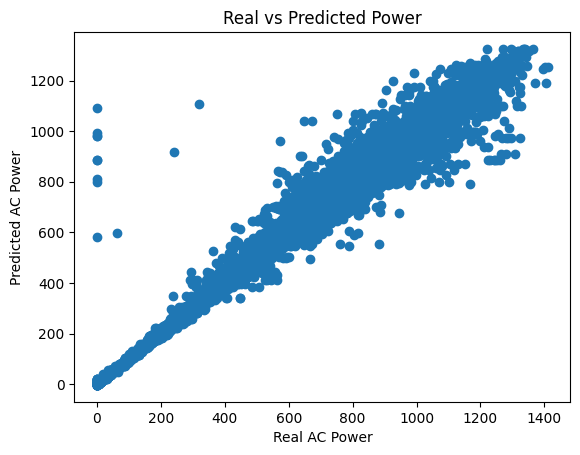

In [34]:
#Visualiser les prédictions
plt.scatter(y_test, pred_xgb)
plt.xlabel("Real AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Real vs Predicted Power")
plt.show()